IRIS DATABASE

Names of columns:['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Dataset shape: (150, 4)
Number of features: 4
Number of samples: 150
Names of Target: ['setosa' 'versicolor' 'virginica']
Iris Dataset loaded successfully!
Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal len

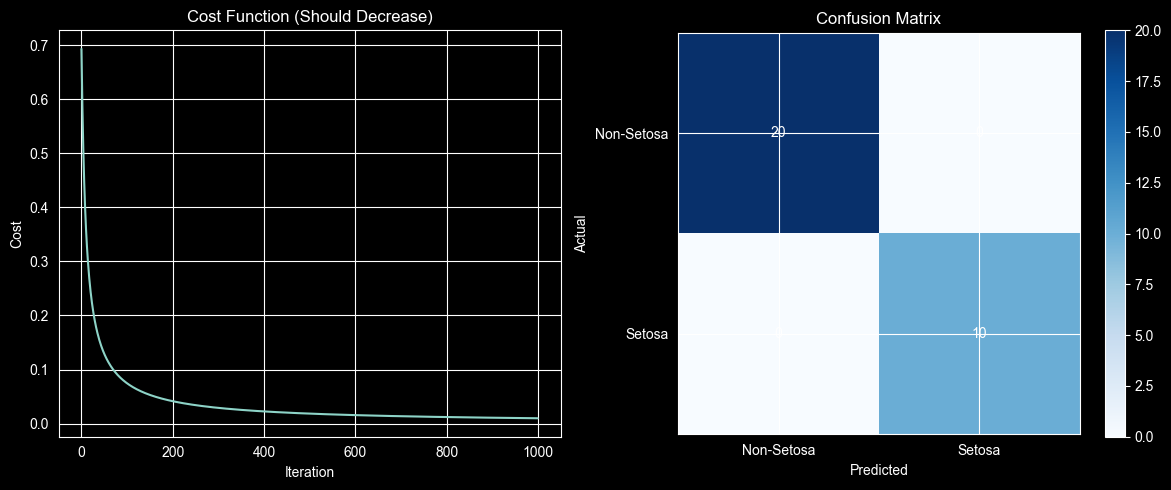


✅ Binary classification on Iris complete!


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix



# ============================================
# PART 1: LOAD AND EXPLORE REAL DATA
# ============================================

print("=" * 60)
print("IRIS DATABASE")
print("=" * 60)

# Load the iris dataset
iris = load_iris()

X = iris.data  # Features
# Convert to BINARY problem: Setosa (class 0) vs NOT Setosa (classes 1 and 2)
y = (iris.target == 0).astype(int)  # 1 = Setosa, 0 = Versicolor/Virginica


print(f"\nNames of columns:{iris.feature_names}")
print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Names of Target: {iris.target_names}")

# Convert to pandas DataFrame (easier to work with)
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_map)

# Display the data
print("Iris Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())


# ============================================
# PART 2: EXPLORE DATA
# ============================================

print("\n" + "=" * 60)
print("DATA EXPLORATION")
print("=" * 60)

print(f"\nMissing values:")
print(df.isnull().sum())

# Check class distribution
print("\nSpecies distribution:")
print(df['species_name'].value_counts())

# ============================================
# PART 3: TRAIN/VALIDATION/TEST SPLIT
# ============================================
print("\n" + "=" * 60)
print("TRAIN/VALIDATION/TEST SPLIT")
print("=" * 60)
# Split into train (60%), validation (20%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# ============================================
# PART 4: SCALE FEATURES (CRITICAL!)
# ============================================

# Scale features for gradient descent
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ============================================
# PART 5:  LOGISTIC REGRESSION CLASS
# ============================================
def sigmoid(z):
    """Convert z to probability between 0 and 1"""
    return 1 / (1 + np.exp(-z))

def logistic_cost(y_true, y_pred_prob):
    """Calculate log loss"""
    epsilon = 1e-15
    y_pred_prob = np.clip(y_pred_prob, epsilon, 1 - epsilon)
    m = len(y_true)
    cost = -1/m * np.sum(y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob))
    return cost

class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        """
        Train logistic regression using gradient descent
        """
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for iteration in range(self.n_iterations):
            # Step 1: Calculate linear output (z = w*X + b)
            z = np.dot(X, self.weights) + self.bias

            # Step 2: Convert to probability using sigmoid
            y_pred_prob = sigmoid(z)

            # Step 3: Calculate cost (log loss)
            cost = logistic_cost(y.reshape(-1, 1), y_pred_prob)
            self.cost_history.append(cost)

            # Step 4: Calculate gradients
            # For logistic regression, dw = (1/m) * X.T * (y_pred - y)
            error = y_pred_prob - y.reshape(-1, 1)
            dw = (1/n_samples) * np.dot(X.T, error)
            db = (1/n_samples) * np.sum(error)

            # Step 5: Update parameters (SAME as linear regression!)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Print progress
            if iteration % 100 == 0:
                print(f"Iteration {iteration:4d}, Cost: {cost:.6f}")

        return self

    def predict_proba(self, X):
        """Return probability predictions"""
        z = np.dot(X, self.weights) + self.bias
        return sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Return class predictions (0 or 1)"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

# ============================================
# PART 6: TRAIN WITH DIFFERENT LEARNING RATES
# ============================================

print("\n" + "=" * 60)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 60)

model = LogisticRegressionGD(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"\nConfusion Matrix:")
print(f"              Predicted")
print(f"              Setosa  Non-Setosa")
print(f"Actual Setosa     {cm[1,1]:3d}       {cm[1,0]:3d}")
print(f"Actual Non-Setosa {cm[0,1]:3d}       {cm[0,0]:3d}")

# Visualize
import os
os.makedirs('week3_logistic_regression', exist_ok=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model.cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function (Should Decrease)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Non-Setosa', 'Setosa'])
plt.yticks(tick_marks, ['Non-Setosa', 'Setosa'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.tight_layout()
plt.savefig('week3_logistic_regression/iris_binary_results.png')
plt.show()

print("\n" + "=" * 60)
print("✅ Binary classification on Iris complete!")
print("=" * 60)

